In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
# !pip install --quiet efficientnet

import math, os, re, warnings, random
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from kaggle_datasets import KaggleDatasets
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import tensorflow.keras.layers as L
from tensorflow.keras import optimizers, applications, Sequential, losses
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
# import efficientnet.tfkeras as efn

def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

seed = 0
seed_everything(seed)
warnings.filterwarnings("ignore")

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# TPU or GPU detection
# Detect hardware, return appropriate distribution strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print(f'Running on TPU {tpu.master()}')
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy()

AUTO = tf.data.experimental.AUTOTUNE
REPLICAS = strategy.num_replicas_in_sync
print(f'REPLICAS: {REPLICAS}')

REPLICAS: 1


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
BATCH_SIZE = 16 * REPLICAS
WARMUP_EPOCHS = 3
WARMUP_LEARNING_RATE = 1e-4 * REPLICAS
EPOCHS = 30
LEARNING_RATE = 3e-5 * REPLICAS
HEIGHT = 192 #512  # using the smallest images in the dataset for fast reproducing
WIDTH = 192  #512  # using the smallest images in the dataset for fast reproducing
CHANNELS = 3
N_CLASSES = 104
ES_PATIENCE = 5

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
model_path = f'model_{HEIGHT}x{WIDTH}.h5'

# GCS_PATH = KaggleDatasets().get_gcs_path('tpu-getting-started') + f'/tfrecords-jpeg-{HEIGHT}x{WIDTH}'
GCS_PATH = "data/tfrecords-jpeg-{}x{}".format(HEIGHT, WIDTH) # get data from local disk (reproducing purposes)

TRAINING_FILENAMES = tf.io.gfile.glob(GCS_PATH + '/train/*.tfrec')
VALIDATION_FILENAMES = tf.io.gfile.glob(GCS_PATH + '/val/*.tfrec')
TEST_FILENAMES = tf.io.gfile.glob(GCS_PATH + '/test/*.tfrec')

CLASSES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 
    'wild geranium', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 
    'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 
    'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 
    'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 
    'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 
    'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 
    'carnation', 'garden phlox', 'love in the mist', 'cosmos',  'alpine sea holly', 
    'ruby-lipped cattleya', 'cape flower', 'great masterwort',  'siam tulip', 
    'lenten rose', 'barberton daisy', 'daffodil',  'sword lily', 'poinsettia', 
    'bolero deep blue',  'wallflower', 'marigold', 'buttercup', 'daisy', 
    'common dandelion', 'petunia', 'wild pansy', 'primula',  'sunflower', 
    'lilac hibiscus', 'bishop of llandaff', 'gaura',  'geranium', 'orange dahlia', 
    'pink-yellow dahlia', 'cautleya spicata',  'japanese anemone', 
    'black-eyed susan', 'silverbush', 'californian poppy',  'osteospermum', 
    'spring crocus', 'iris', 'windflower',  'tree poppy', 'gazania', 'azalea', 
    'water lily',  'rose', 'thorn apple', 'morning glory', 'passion flower',  
    'lotus', 'toad lily', 'anthurium', 'frangipani',  'clematis', 'hibiscus', 
    'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ', 
    'watercress',  'canna lily', 'hippeastrum ', 'bee balm', 'pink quill',  
    'foxglove', 'bougainvillea', 'camellia', 'mallow',  'mexican petunia',  
    'bromelia', 'blanket flower', 'trumpet creeper',  'blackberry lily', 
    'common tulip', 'wild rose']

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# Datasets utility functions
AUTO = tf.data.experimental.AUTOTUNE # instructs the API to read from multiple files if available.

def decode_image(image_data):
    image = tf.image.decode_jpeg(image_data, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, [HEIGHT, WIDTH, 3])
    return image

def read_labeled_tfrecord(example):
    LABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string), # tf.string means bytestring
        "class": tf.io.FixedLenFeature([], tf.int64),  # shape [] means single element
    }
    example = tf.io.parse_single_example(example, LABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    label = tf.cast(example['class'], tf.int32)
    return image, label

def read_unlabeled_tfrecord(example):
    UNLABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string), # tf.string means bytestring
        "id": tf.io.FixedLenFeature([], tf.string),  # shape [] means single element
        # class is missing, this competitions's challenge is to predict flower classes for the test dataset
    }
    example = tf.io.parse_single_example(example, UNLABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    idnum = example['id']
    return image, idnum # returns a dataset of image(s)

def load_dataset(filenames, labeled=True, ordered=False):
    ignore_order = tf.data.Options()
    if not ordered:
        ignore_order.experimental_deterministic = False # disable order, increase speed

    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=AUTO) # automatically interleaves reads from multiple files
    dataset = dataset.with_options(ignore_order) # uses data as soon as it streams in, rather than in its original order
    dataset = dataset.map(read_labeled_tfrecord if labeled else read_unlabeled_tfrecord, num_parallel_calls=AUTO)
    # returns a dataset of (image, label) pairs if labeled=True or (image, id) pairs if labeled=False
    return dataset

def data_augment(image, label):
    crop_size = tf.random.uniform([], int(HEIGHT*.7), HEIGHT, dtype=tf.int32)
        
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_saturation(image, lower=0, upper=2)

#     image = tf.image.random_saturation(image, lower=0, upper=2)
#     image = tf.image.random_contrast(image, lower=.8, upper=2)
#     image = tf.image.random_brightness(image, max_delta=.2)
#     image = tf.image.adjust_gamma(image, gamma=.6)

    image = tf.image.random_crop(image, size=[crop_size, crop_size, CHANNELS])
    image = tf.image.resize(image, size=[HEIGHT, WIDTH])

    return image, label

def get_training_dataset():
    dataset = load_dataset(TRAINING_FILENAMES, labeled=True)
    dataset = dataset.map(data_augment, num_parallel_calls=AUTO)
    dataset = dataset.repeat() # the training dataset must repeat for several epochs
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTO) # prefetch next batch while training (autotune prefetch buffer size)
    return dataset

def get_training_dataset_preview(ordered=True):
    dataset = load_dataset(TRAINING_FILENAMES, labeled=True, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.cache()
    dataset = dataset.prefetch(AUTO)
    return dataset

def get_validation_dataset(ordered=False):
    dataset = load_dataset(VALIDATION_FILENAMES, labeled=True, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.cache()
    dataset = dataset.prefetch(AUTO)
    return dataset

def get_test_dataset(ordered=False):
    dataset = load_dataset(TEST_FILENAMES, labeled=False, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTO)
    return dataset

def count_data_items(filenames):
    # the number of data items is written in the name of the .tfrec files, i.e. flowers00-230.tfrec = 230 data items
    n = [int(re.compile(r"-([0-9]*)\.").search(filename).group(1)) for filename in filenames]
    return np.sum(n)

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# Train data
NUM_TRAINING_IMAGES = count_data_items(TRAINING_FILENAMES)
train_dataset = get_training_dataset_preview(ordered=True)
y_train = next(iter(train_dataset.unbatch().map(lambda image, label: label).batch(NUM_TRAINING_IMAGES))).numpy()
print(f'Number of training images {NUM_TRAINING_IMAGES}')

# Validation data
NUM_VALIDATION_IMAGES = count_data_items(VALIDATION_FILENAMES)
valid_dataset = get_validation_dataset(ordered=True)
y_valid = next(iter(valid_dataset.unbatch().map(lambda image, label: label).batch(NUM_VALIDATION_IMAGES))).numpy()
print(f'Number of validation images {NUM_VALIDATION_IMAGES}')

# Test data
NUM_TEST_IMAGES = count_data_items(TEST_FILENAMES)
print(f'Number of test images {NUM_TEST_IMAGES}')
test_dataset = get_test_dataset(ordered=True)

Number of training images 12753
Number of validation images 3712
Number of test images 7382


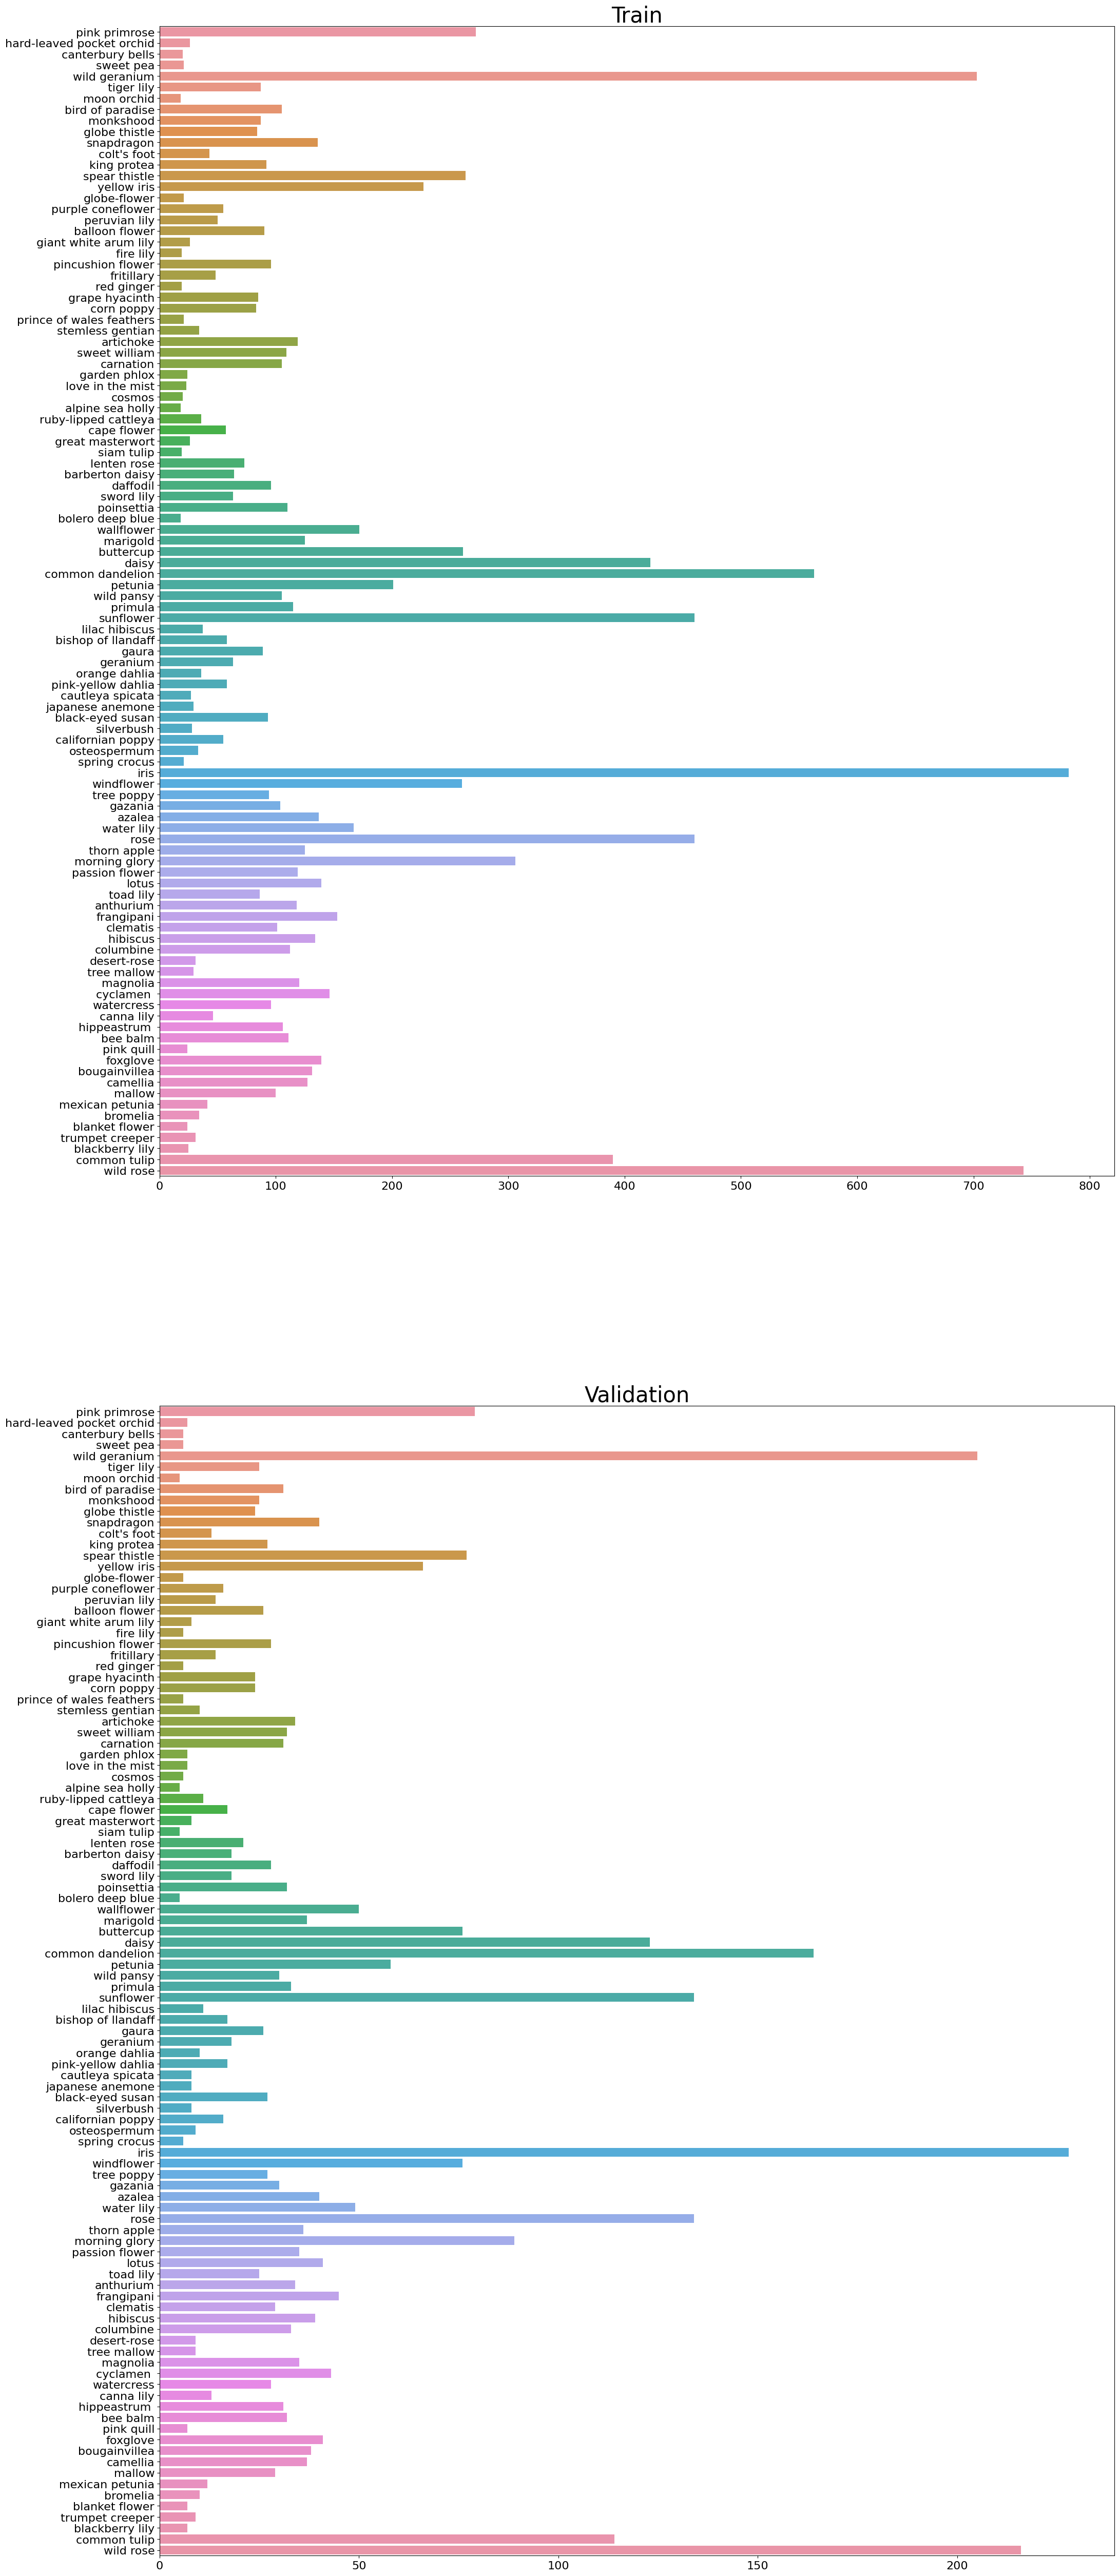

In [7]:
# --- [CELL 6]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# === BEFORE (original) ===
# train_agg = np.asarray([[label, (y_train == index).sum()] for index, label in enumerate(CLASSES)])
# valid_agg = np.asarray([[label, (y_valid == index).sum()] for index, label in enumerate(CLASSES)])
# 
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 64))
# 
# ax1 = sns.barplot(x=train_agg[...,1], y=train_agg[...,0], order=CLASSES, ax=ax1)
# ax1.set_title('Train', fontsize=30)
# ax1.tick_params(labelsize=16)
# 
# ax2 = sns.barplot(x=valid_agg[...,1], y=valid_agg[...,0], order=CLASSES, ax=ax2)
# ax2.set_title('Validation', fontsize=30)
# ax2.tick_params(labelsize=16)
# 
# plt.show()

# === AFTER (edited) ===
train_agg = np.array([[label, int((y_train == index).sum())] for index, label in enumerate(CLASSES)], dtype=object)
valid_agg = np.array([[label, int((y_valid == index).sum())] for index, label in enumerate(CLASSES)], dtype=object)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 64))

ax1 = sns.barplot(x=train_agg[:, 1].astype(int), y=train_agg[:, 0], order=CLASSES, ax=ax1)
ax1.set_title('Train', fontsize=30)
ax1.tick_params(labelsize=16)

ax2 = sns.barplot(x=valid_agg[:, 1].astype(int), y=valid_agg[:, 0], order=CLASSES, ax=ax2)
ax2.set_title('Validation', fontsize=30)
ax2.tick_params(labelsize=16)

plt.show()

In [1]:
# manual inspection results
if_pass = True
assert if_pass, "Manual inspection failed."